In [1]:
!pip install optuna rtdl_revisiting_models -q

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import numpy as np, pandas as pd, torch, torch.nn as nn, optuna, time
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr
from scipy.ndimage import gaussian_filter1d
from itertools import permutations
from tqdm.auto import tqdm
from rtdl_revisiting_models import FTTransformer
optuna.logging.set_verbosity(optuna.logging.WARNING)

def seed_everything(seed=42):
    np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
seed_everything(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATA_DIR = "/content/drive/MyDrive/Armas"
df_p1 = pd.read_json(f"{DATA_DIR}/ARMAS_STATIC_20132023_P1.json", lines=True)
df_p2 = pd.read_json(f"{DATA_DIR}/ARMAS_STATIC_20132023_P2.json", lines=True)
df_p3 = pd.read_json(f"{DATA_DIR}/ARMAS_STATIC_20132023_P3.json", lines=True)
df_p1["partition"], df_p2["partition"], df_p3["partition"] = "P1","P2","P3"
df = pd.concat([df_p1, df_p2, df_p3], ignore_index=True)
print(df.shape, "| Device:", DEVICE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(92476, 49) | Device: cuda


In [3]:
target_col = "ARMAS"
drop_cols = ["ARMAS","NAIRASV2","NAIRASV3","Datetime","Vehicle_ID","partition"]
feature_cols = [c for c in df.columns if c not in drop_cols]
splits = list(permutations(["P1","P2","P3"], 3))
TAIL_THR = 20.0
Y_CLIP = float(df[target_col].max()) * 1.5
N_TRIALS, MAX_EPOCHS, PATIENCE = 40, 200, 16

def evaluate_regression(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    if len(y_true) > 1 and np.std(y_true) > 0 and np.std(y_pred) > 0:
        pearson, r2 = pearsonr(y_true, y_pred)[0], r2_score(y_true, y_pred)
    else: pearson = r2 = np.nan
    return {"MAE": mean_absolute_error(y_true,y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true,y_pred)),
            "R2": r2, "Pearson_r": pearson, "Bias": np.mean(y_pred-y_true),
            "Underestimation_%": np.mean(y_pred<y_true)*100}

def regression_metrics_subset(d):
    yt, yp = d["y_true"].values, d["y_pred"].values
    out = {"n": len(d), "RMSE": np.sqrt(mean_squared_error(yt,yp)),
           "MAE": mean_absolute_error(yt,yp), "Bias": np.mean(yp-yt),
           "Underestimation_%": np.mean(yp<yt)*100, "Median_AE": np.median(np.abs(yp-yt))}
    if len(d)>1 and np.std(yt)>0 and np.std(yp)>0:
        out["R2"], out["Pearson_r"] = r2_score(yt,yp), pearsonr(yt,yp)[0]
    else: out["R2"]=out["Pearson_r"]=np.nan
    return pd.Series(out)

def compute_density_weights(y, n_bins=50, sigma=2.0, max_ratio=50.0):
    y = np.asarray(y, dtype=float)
    edges = np.linspace(y.min(), y.max()+1e-9, n_bins+1)
    idx = np.clip(np.digitize(y, edges)-1, 0, n_bins-1)
    counts = np.bincount(idx, minlength=n_bins).astype(float)
    smoothed = np.clip(gaussian_filter1d(counts, sigma=sigma, mode="nearest"), 1e-6, None)
    w = 1.0/smoothed[idx]; w = np.clip(w/w.min(), 1.0, max_ratio)
    return w * (len(w)/w.sum())

print(len(feature_cols), "features,", len(splits), "rotations | Y_CLIP =", round(Y_CLIP,1))

43 features, 6 rotations | Y_CLIP = 63.6


In [4]:
# ft wrapper, training harness

class FTWrapper(nn.Module):
    def __init__(self, n_features, n_blocks, d_block, attention_n_heads,
                 attention_dropout, ffn_dropout, residual_dropout):
        super().__init__()
        self.ft = FTTransformer(
            n_cont_features=n_features, cat_cardinalities=[], d_out=1,
            n_blocks=n_blocks, d_block=d_block, attention_n_heads=attention_n_heads,
            attention_dropout=attention_dropout, ffn_d_hidden_multiplier=4/3,
            ffn_dropout=ffn_dropout, residual_dropout=residual_dropout)
    def forward(self, x):
        return self.ft(x, None)

def predict_ft(model, X, device=DEVICE, bs=2048):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X), bs):
            xb = torch.tensor(X[i:i+bs], dtype=torch.float32).to(device)
            out.append(model(xb).cpu().numpy().ravel())
    return np.concatenate(out)

def train_ft(model, X_tr, y_tr, X_va, y_va, w_tr=None,
             lr=1e-4, weight_decay=1e-5, batch_size=256,
             max_epochs=MAX_EPOCHS, patience=PATIENCE, device=DEVICE):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    Xtr = torch.tensor(X_tr, dtype=torch.float32)
    ytr = torch.tensor(y_tr, dtype=torch.float32).view(-1,1)
    cols = [Xtr, ytr]
    if w_tr is not None:
        cols.append(torch.tensor(w_tr, dtype=torch.float32).view(-1,1))
    dl = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(*cols),
                                     batch_size=batch_size, shuffle=True)
    yva_np = np.asarray(y_va, dtype=np.float32)
    best_val, best_state, bad = np.inf, None, 0
    for _ in range(max_epochs):
        model.train()
        for batch in dl:
            opt.zero_grad()
            parts = [t.to(device) for t in batch]
            pred = model(parts[0])
            loss = ((pred-parts[1])**2).mean() if w_tr is None else (parts[2]*(pred-parts[1])**2).mean()
            loss.backward(); opt.step()
        model.eval()
        sq_sum, n = 0.0, 0
        with torch.no_grad():
            for i in range(0, len(X_va), 2048):
                xb = torch.tensor(X_va[i:i+2048], dtype=torch.float32).to(device)
                pb = model(xb).cpu().numpy().ravel()
                sq_sum += float(np.sum((pb - yva_np[i:i+2048])**2)); n += len(pb)
        vloss = sq_sum / n
        if vloss < best_val - 1e-6:
            best_val, bad = vloss, 0
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    return model, best_val

In [5]:
# time test

def make_objective_ft(Xtr_s, ytr, Xva_s, yva, y_mean, y_std):
    def objective(trial):
        n_blocks = trial.suggest_int("n_blocks", 1, 3)
        d_block  = trial.suggest_categorical("d_block", [64, 128, 192])
        n_heads  = trial.suggest_categorical("attention_n_heads", [4, 8])
        att_drop = trial.suggest_float("attention_dropout", 0.0, 0.4)
        ffn_drop = trial.suggest_float("ffn_dropout", 0.0, 0.4)
        res_drop = trial.suggest_float("residual_dropout", 0.0, 0.2)
        lr       = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
        wd       = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        seed_everything(42)
        model = FTWrapper(Xtr_s.shape[1], n_blocks, d_block, n_heads, att_drop, ffn_drop, res_drop)
        model, _ = train_ft(model, Xtr_s, ytr, Xva_s, yva, lr=lr, weight_decay=wd, batch_size=256)
        yva_pred = predict_ft(model, Xva_s) * y_std + y_mean
        rmse = np.sqrt(mean_squared_error(yva*y_std+y_mean, yva_pred))
        del model; torch.cuda.empty_cache()
        return rmse
    return objective

t0 = time.time()
train_p, val_p, test_p = splits[0]
tr = df[df["partition"]==train_p]; va = df[df["partition"]==val_p]
xs = StandardScaler().fit(tr[feature_cols].values)
Xtr_s, Xva_s = xs.transform(tr[feature_cols].values), xs.transform(va[feature_cols].values)
y_mean, y_std = tr[target_col].mean(), tr[target_col].std()
ytr = (tr[target_col].values - y_mean)/y_std
yva = (va[target_col].values - y_mean)/y_std

st = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
st.optimize(make_objective_ft(Xtr_s, ytr, Xva_s, yva, y_mean, y_std), n_trials=3, show_progress_bar=False)
elapsed = time.time() - t0
print(f"3 Trials, 1 Split: {elapsed:.0f}s | bester Val-RMSE: {st.best_value:.3f}")
print(f"EIN Modell (40x6): {elapsed/3*40*6/3600:.2f} h")
print(f"BEIDE Modelle: {2*elapsed/3*40*6/3600:.2f} h")

3 Trials, 1 Split: 182s | bester Val-RMSE: 3.637
EIN Modell (40x6): 4.05 h
BEIDE Modelle: 8.09 h


In [6]:
# Budget + Output-Ordner auf Drive
N_TRIALS = 25
OUT_DIR = "/content/drive/MyDrive/Armas/ft_results"
os.makedirs(OUT_DIR, exist_ok=True)
print("N_TRIALS =", N_TRIALS, "| Output:", OUT_DIR)

N_TRIALS = 25 | Output: /content/drive/MyDrive/Armas/ft_results


In [7]:
ft_results, ft_best_params_by_split, ft_predictions_all = [], [], []

for train_p, val_p, test_p in tqdm(splits, desc="FT baseline rotations"):
    split_name = f"{train_p[-1]}{val_p[-1]}{test_p[-1]}"
    tr = df[df["partition"]==train_p]; va = df[df["partition"]==val_p]; te = df[df["partition"]==test_p]

    xs = StandardScaler().fit(tr[feature_cols].values)
    Xtr_s = xs.transform(tr[feature_cols].values)
    Xva_s = xs.transform(va[feature_cols].values)
    Xte_s = xs.transform(te[feature_cols].values)

    y_mean, y_std = tr[target_col].mean(), tr[target_col].std()
    ytr = (tr[target_col].values - y_mean)/y_std
    yva = (va[target_col].values - y_mean)/y_std
    y_test = te[target_col].values

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(make_objective_ft(Xtr_s, ytr, Xva_s, yva, y_mean, y_std),
                   n_trials=N_TRIALS, show_progress_bar=False)
    bp = study.best_params

    seed_everything(42)
    model = FTWrapper(Xtr_s.shape[1], bp["n_blocks"], bp["d_block"], bp["attention_n_heads"],
                      bp["attention_dropout"], bp["ffn_dropout"], bp["residual_dropout"])
    model, _ = train_ft(model, Xtr_s, ytr, Xva_s, yva,
                        lr=bp["lr"], weight_decay=bp["weight_decay"], batch_size=256)
    y_test_pred = predict_ft(model, Xte_s) * y_std + y_mean
    del model; torch.cuda.empty_cache()

    test_m = evaluate_regression(y_test, y_test_pred)
    ft_results.append({"Model":"FT-Transformer","Split":split_name,
                       "Train_partition":train_p,"Validation_partition":val_p,"Test_partition":test_p,
                       **{f"Test_{k}":v for k,v in test_m.items()}})
    ft_best_params_by_split.append({"Split":split_name, **bp, "Best_Validation_RMSE":study.best_value})

    pred_df = pd.DataFrame({"Model":"FT-Transformer","Split":split_name,
                            "Train_partition":train_p,"Validation_partition":val_p,"Test_partition":test_p,
                            "y_true":y_test,"y_pred":y_test_pred})
    pred_df["residual"]=pred_df["y_pred"]-pred_df["y_true"]
    pred_df["abs_error"]=pred_df["residual"].abs()
    pred_df["sq_error"]=pred_df["residual"]**2
    pred_df["underpred"]=pred_df["y_pred"]<pred_df["y_true"]
    pred_df["tail_ge_15"]=pred_df["y_true"]>=15
    pred_df["tail_ge_20"]=pred_df["y_true"]>=20
    pred_df["pred_ge_15"]=pred_df["y_pred"]>=15
    pred_df["pred_ge_20"]=pred_df["y_pred"]>=20
    ft_predictions_all.append(pred_df)

    # nach JEDEM Split nach Drive sichern (überlebt Session-Abbruch)
    pd.concat(ft_predictions_all, ignore_index=True).to_csv(f"{OUT_DIR}/ft_predictions_progress.csv", index=False)
    pd.DataFrame(ft_results).to_csv(f"{OUT_DIR}/ft_results_progress.csv", index=False)

print("Baseline-FT fertig.")

FT baseline rotations:   0%|          | 0/6 [00:00<?, ?it/s]

Baseline-FT fertig.


Notes (for Methods chapter):

- Hyperparameters for the MLP and FT-Transformer were tuned with Optuna using the TPE sampler; XGBoost was tuned via exhaustive grid search following the search space of Sanjib et al. (2025)

- Tuning budget: 40 trials per rotation for the MLP, 25 trials per rotation for the FT-Transformer.

- The reduced FT-Transformer budget reflects its substantially higher per-trial computational cost (attention scales quadratically; training was GPU-bound), which makes a larger budget impractical

- TPE concentrates sampling in promising regions of the search space, so most of the improvement is realized within the first ~20 trials; further trials yield diminishing returns below the cross-validation variance across the six rotations

- Empirically, the FT-Transformer reached a validation RMSE on par with the best models within few trials during a test run, confirming the budget is sufficient to characterise the architecture's performance

- This budget asymmetry is therefore not expected to materially affect the model comparison; all models share the same partitioning, cross-validation scheme, selection protocol, and evaluation metrics.


In [8]:
ft_results = pd.DataFrame(ft_results)
ft_best_params_by_split = pd.DataFrame(ft_best_params_by_split)
ft_predictions_all = pd.concat(ft_predictions_all, ignore_index=True)
ft_results.to_csv(f"{OUT_DIR}/ft_results_final.csv", index=False)
ft_predictions_all.to_csv(f"{OUT_DIR}/ft_predictions_all.csv", index=False)
print("Rows:", len(ft_predictions_all), "| y_pred max:", round(ft_predictions_all['y_pred'].max(),2))
ft_results

Rows: 184952 | y_pred max: 24.07


,Model,Split,Train_partition,Validation_partition,Test_partition,Test_MAE,Test_RMSE,Test_R2,Test_Pearson_r,Test_Bias,Test_Underestimation_%
0,FT-Transformer,123,P1,P2,P3,2.681369,3.651015,0.538916,0.735155,-0.174633,48.421986
1,FT-Transformer,132,P1,P3,P2,2.616648,3.673132,0.538036,0.734685,-0.176939,50.355670
2,FT-Transformer,213,P2,P1,P3,2.678668,3.614494,0.548094,0.740559,0.010211,44.440274
3,FT-Transformer,231,P2,P3,P1,2.695279,3.728569,0.507296,0.714260,-0.097555,49.382335
4,FT-Transformer,312,P3,P1,P2,2.650840,3.696655,0.532100,0.730091,0.057965,43.982850
5,FT-Transformer,321,P3,P2,P1,2.651155,3.656165,0.526245,0.726448,-0.062944,47.408894


In [9]:
# Tail/Bulk-Metriken
for regime, sub in {"Overall": ft_predictions_all,
                    "Tail(>=20)": ft_predictions_all[ft_predictions_all["y_true"]>=20]}.items():
    rows = []
    for split, g in (sub.groupby("Split")):
        rows.append(regression_metrics_subset(g))
    m = pd.DataFrame(rows)
    print(f"\n{regime}:")
    print(m[["RMSE","MAE","Bias","Underestimation_%"]].agg(["mean","std"]).round(3))

# Recall
from sklearn.metrics import recall_score, precision_score, f1_score
rows = []
for split, g in ft_predictions_all.groupby("Split"):
    a=(g["y_true"]>=20).astype(int); b=(g["y_pred"]>=20).astype(int)
    rows.append({"Recall":recall_score(a,b,zero_division=0),
                 "Precision":precision_score(a,b,zero_division=0),
                 "F1":f1_score(a,b,zero_division=0)})
print("\nFT baseline — Recall Mean ± Std:")
print(pd.DataFrame(rows)[["Recall","Precision","F1"]].agg(["mean","std"]).round(3))


Overall:
       RMSE    MAE   Bias  Underestimation_%
mean  3.670  2.662 -0.074             47.332
std   0.039  0.028  0.096              2.612

Tail(>=20):
       RMSE    MAE   Bias  Underestimation_%
mean  9.223  8.226 -8.206             99.456
std   0.549  0.488  0.485              1.075

FT baseline — Recall Mean ± Std:
      Recall  Precision     F1
mean   0.029      0.451  0.051
std    0.027      0.318  0.042


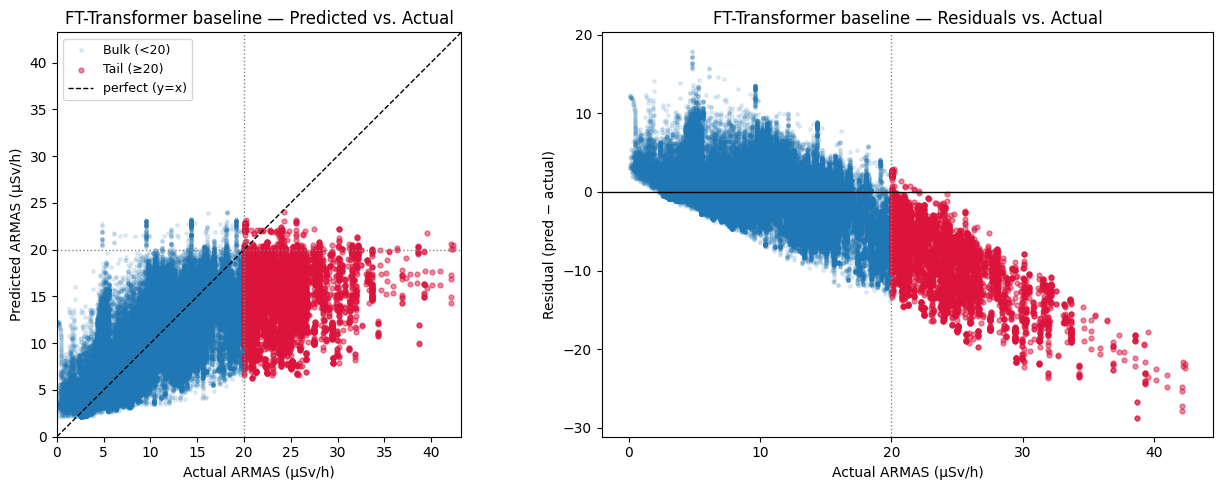

In [10]:
import matplotlib.pyplot as plt
TAIL_THR = 20.0
p = ft_predictions_all
is_tail = p["y_true"] >= TAIL_THR
resid = p["y_pred"] - p["y_true"]
hi = max(p["y_true"].max(), p["y_pred"].max()) * 1.02

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.scatter(p.loc[~is_tail,"y_true"], p.loc[~is_tail,"y_pred"], s=6, alpha=0.12, label="Bulk (<20)")
ax.scatter(p.loc[is_tail,"y_true"],  p.loc[is_tail,"y_pred"],  s=12, alpha=0.5, color="crimson", label="Tail (≥20)")
ax.plot([0, hi],[0, hi], "k--", lw=1, label="perfect (y=x)")
ax.axvline(TAIL_THR, color="grey", ls=":", lw=1); ax.axhline(TAIL_THR, color="grey", ls=":", lw=1)
ax.set(xlim=(0,hi), ylim=(0,hi), xlabel="Actual ARMAS (µSv/h)",
       ylabel="Predicted ARMAS (µSv/h)", title="FT-Transformer baseline — Predicted vs. Actual")
ax.set_aspect("equal", adjustable="box"); ax.legend(loc="upper left", fontsize=9)

ax = axes[1]
ax.scatter(p.loc[~is_tail,"y_true"], resid[~is_tail], s=6, alpha=0.12)
ax.scatter(p.loc[is_tail,"y_true"],  resid[is_tail],  s=12, alpha=0.5, color="crimson")
ax.axhline(0, color="k", lw=1); ax.axvline(TAIL_THR, color="grey", ls=":", lw=1)
ax.set(xlabel="Actual ARMAS (µSv/h)", ylabel="Residual (pred − actual)",
       title="FT-Transformer baseline — Residuals vs. Actual")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_ft_baseline_errors.pdf", bbox_inches="tight")
plt.show()

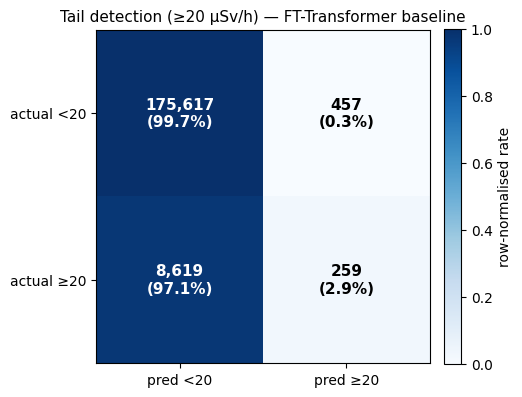

In [11]:
from sklearn.metrics import confusion_matrix
yt = (p["y_true"] >= TAIL_THR).astype(int)
yp = (p["y_pred"] >= TAIL_THR).astype(int)
cm = confusion_matrix(yt, yp, labels=[0,1])
cmn = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks([0,1], ["pred <20","pred ≥20"]); ax.set_yticks([0,1], ["actual <20","actual ≥20"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]:,}\n({cmn[i,j]:.1%})", ha="center", va="center",
                fontsize=11, fontweight="bold", color="white" if cmn[i,j] > 0.5 else "black")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="row-normalised rate")
ax.set_title("Tail detection (≥20 µSv/h) — FT-Transformer baseline", fontsize=11)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_ft_baseline_confusion.pdf", bbox_inches="tight")
plt.show()

In [12]:
ft_best_params_by_split.to_csv(f"{OUT_DIR}/ft_best_params_final.csv", index=False)
print("gespeichert")

gespeichert


In [13]:
import os
files = os.listdir(OUT_DIR)
print("Dateien in Drive:")
for f in sorted(files):
    print(" ", f)

Dateien in Drive:
  fig_ft_baseline_confusion.pdf
  fig_ft_baseline_errors.pdf
  ft_best_params_final.csv
  ft_predictions_all.csv
  ft_predictions_progress.csv
  ft_results_final.csv
  ft_results_progress.csv


Weighted FT Transformer

In [5]:
def tail_rmse(y_true, y_pred, thr=TAIL_THR):
    m = np.asarray(y_true) >= thr
    if m.sum() == 0: return np.inf
    e = np.asarray(y_pred)[m] - np.asarray(y_true)[m]
    return np.sqrt(np.mean(e**2))

def make_objective_ft_weighted(Xtr_s, ytr_log, Xva_s, y_val_orig, w_tr):
    def objective(trial):
        n_blocks = trial.suggest_int("n_blocks", 1, 3)
        d_block  = trial.suggest_categorical("d_block", [64, 128, 192])
        n_heads  = trial.suggest_categorical("attention_n_heads", [4, 8])
        att_drop = trial.suggest_float("attention_dropout", 0.0, 0.4)
        ffn_drop = trial.suggest_float("ffn_dropout", 0.0, 0.4)
        res_drop = trial.suggest_float("residual_dropout", 0.0, 0.2)
        lr       = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
        wd       = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        seed_everything(42)
        model = FTWrapper(Xtr_s.shape[1], n_blocks, d_block, n_heads, att_drop, ffn_drop, res_drop)
        model, _ = train_ft(model, Xtr_s, ytr_log, Xva_s, np.log1p(y_val_orig), w_tr=w_tr,
                            lr=lr, weight_decay=wd, batch_size=256)
        yva_pred = np.clip(np.expm1(predict_ft(model, Xva_s)), 0, Y_CLIP)
        crit = tail_rmse(y_val_orig, yva_pred)
        del model; torch.cuda.empty_cache()
        return crit
    return objective

In [6]:
# test

tr=df[df["partition"]==splits[0][0]]; va=df[df["partition"]==splits[0][1]]
xs=StandardScaler().fit(tr[feature_cols].values)
Xtr_s,Xva_s=xs.transform(tr[feature_cols].values),xs.transform(va[feature_cols].values)
y_tr,y_va=tr[target_col].values,va[target_col].values
st=optuna.create_study(direction="minimize",sampler=optuna.samplers.TPESampler(seed=42))
st.optimize(make_objective_ft_weighted(Xtr_s,np.log1p(y_tr),Xva_s,y_va,compute_density_weights(y_tr)),
            n_trials=2,show_progress_bar=False)
print("Trials:",len(st.trials),"| Tail-RMSE:",round(st.best_value,3))

Trials: 2 | Tail-RMSE: 7.602


In [9]:
N_TRIALS = 15
OUT_DIR = "/content/drive/MyDrive/Armas/ft_results"
import os
os.makedirs(OUT_DIR, exist_ok=True)
print("N_TRIALS =", N_TRIALS, "| OUT_DIR =", OUT_DIR)

N_TRIALS = 15 | OUT_DIR = /content/drive/MyDrive/Armas/ft_results


In [ ]:
# Permutation Importance — Baseline FT (Split 231)

import matplotlib.pyplot as plt

def permutation_importance(predict_fn, X, y_true, feature_names, n_repeats=5, seed=42):
    rng = np.random.default_rng(seed)
    base = np.sqrt(mean_squared_error(y_true, predict_fn(X)))
    imp = []
    for j in range(X.shape[1]):
        scores = []
        for _ in range(n_repeats):
            Xp = X.copy()
            col = Xp[:, j].copy(); rng.shuffle(col); Xp[:, j] = col
            scores.append(np.sqrt(mean_squared_error(y_true, predict_fn(Xp))) - base)
        imp.append(np.mean(scores))
    return pd.DataFrame({"feature": feature_names, "importance": imp}).sort_values("importance", ascending=False)

shap_split = "231"
ft_best = pd.read_csv(f"{OUT_DIR}/ft_best_params_final.csv").set_index("Split")
bp = ft_best.loc[shap_split]
train_p, val_p, test_p = "P"+shap_split[0], "P"+shap_split[1], "P"+shap_split[2]
tr = df[df["partition"]==train_p]; va = df[df["partition"]==val_p]; te = df[df["partition"]==test_p]

xs = StandardScaler().fit(tr[feature_cols].values)
Xtr_s, Xva_s, Xte_s = (xs.transform(tr[feature_cols].values),
                       xs.transform(va[feature_cols].values),
                       xs.transform(te[feature_cols].values))
y_mean, y_std = tr[target_col].mean(), tr[target_col].std()
ytr = (tr[target_col].values-y_mean)/y_std
yva = (va[target_col].values-y_mean)/y_std
y_test = te[target_col].values

seed_everything(42)
model = FTWrapper(Xtr_s.shape[1], int(bp["n_blocks"]), int(bp["d_block"]), int(bp["attention_n_heads"]),
                  float(bp["attention_dropout"]), float(bp["ffn_dropout"]), float(bp["residual_dropout"]))
model, _ = train_ft(model, Xtr_s, ytr, Xva_s, yva,
                    lr=float(bp["lr"]), weight_decay=float(bp["weight_decay"]), batch_size=256)

predict_fn = lambda X: predict_ft(model, X) * y_std + y_mean
pi = permutation_importance(predict_fn, Xte_s, y_test, feature_cols, n_repeats=5)
pi.to_csv(f"{OUT_DIR}/ft_permutation_importance.csv", index=False)

top = pi.head(15).iloc[::-1]
plt.figure(figsize=(7,5))
plt.barh(top["feature"], top["importance"], color="#1D9E75")
plt.xlabel("Increase in RMSE when feature is permuted (µSv/h)")
plt.title(f"Permutation importance — FT-Transformer baseline (split {shap_split})")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_ft_permutation_importance.pdf", bbox_inches="tight"); plt.show()
pi.head(15)